<h1 align="center">
Customer Lifetime Value (CLV) optimization </h1>


### 📌 Problem Statement

An e-commerce company notices that overall sales have stagnated, even though the number of new customers is increasing.
After analysis, the team discovers that many customers purchase only once, which lowers the average Customer Lifetime Value (CLV) and reduces long-term profitability.


In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from lifetimes import BetaGeoFitter, GammaGammaFitter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lifetimes.utils import summary_data_from_transaction_data


In [4]:
# Data similation
data = {
    'customer_id': np.random.randint(1, 101, 500),
    'order_date': pd.date_range('2024-01-01', periods=500, freq='D'),
    'amount': np.random.uniform(20, 300, 500)
}
df = pd.DataFrame(data)



In [5]:
df.head()

,customer_id,order_date,amount
0,59,2024-01-01,198.577826
1,62,2024-01-02,39.369109
2,19,2024-01-03,52.930012
3,75,2024-01-04,107.504996
4,6,2024-01-05,153.131011


In [6]:
# Prepare Data for CLV Model


summary = summary_data_from_transaction_data(
    df, 
    customer_id_col='customer_id', 
    datetime_col='order_date', 
    monetary_value_col='amount', 
    observation_period_end=df['order_date'].max()
)
summary.head()


,frequency,recency,T,monetary_value
customer_id,,,,
1,3.0,413.0,424.0,160.044216
2,2.0,433.0,440.0,167.607491
3,5.0,342.0,354.0,210.809859
4,7.0,295.0,373.0,125.138144
5,4.0,408.0,464.0,158.668561


| **Column**         | **Meaning**                  | **Detailed Explanation**                                                                                                                                                      |
| ------------------ | ---------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **customer_id**    | Customer identifier          | A unique number that identifies each customer.                                                                                                                                |
| **frequency**      | Purchase frequency           | Number of **repeat purchases** made by the customer (the first purchase is not counted). Example: a value of `3` means the customer made **4 total purchases**.               |
| **recency**        | Recency (in days)            | The time (in days) between the **first purchase** and the **last purchase** during the observation period. A higher value means the customer stayed active for a longer time. |
| **T**              | Observation period (in days) | The total time (in days) between the **first purchase** and the **end of the observation window**. It represents how long the customer’s behavior was tracked.                |
| **monetary_value** | Average monetary value       | The **average amount spent per transaction** by the customer. Example: `98.66` means the customer spends about **$98.66 per purchase**.                                       |


In [7]:
# Fit CLV Model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])


<lifetimes.BetaGeoFitter: fitted with 100 subjects, a: 0.00, alpha: 307.51, b: 0.00, r: 3.00>

In [8]:
#Gamma-Gamma for monetary value
# Keep only rows with positive monetary value
summary_positive = summary[summary['monetary_value'] > 0]

# Fit the Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary_positive['frequency'], summary_positive['monetary_value'])

# Calculate  expected average lifetime value
summary['expected_average_lifetime_value'] = ggf.conditional_expected_average_profit(summary['frequency'], summary['monetary_value'])


In [9]:
# Predict Customer Lifetime Value
summary['pred_purchases_6m'] = bgf.predict(180, summary['frequency'], summary['recency'], summary['T'])
summary['predicted_clv'] = ggf.customer_lifetime_value(
    bgf, summary['frequency'], summary['recency'], summary['T'], summary['monetary_value'], time=6, freq='D', discount_rate=0.01
)
# Sort customers by predicted CLV and select top 100
summary.sort_values('predicted_clv', ascending=False).head(10)

,frequency,recency,T,monetary_value,expected_average_lifetime_value,pred_purchases_6m,predicted_clv
customer_id,,,,,,,
88,6.0,301.0,310.0,219.040593,224.723263,2.623848,569.540507
75,10.0,490.0,496.0,188.286867,191.249159,2.912536,538.032849
17,7.0,316.0,362.0,195.309983,199.703215,2.688910,518.679730
31,8.0,288.0,368.0,176.667026,180.185081,2.931492,510.205841
16,6.0,222.0,288.0,182.664279,187.518342,2.720781,492.805161
95,7.0,414.0,472.0,212.169006,216.890337,2.309467,483.826775
78,8.0,311.0,420.0,174.579518,178.062113,2.721959,468.156420
3,5.0,342.0,354.0,210.809859,217.434259,2.177220,457.265275
45,6.0,277.0,349.0,186.523014,191.464975,2.467979,456.424153


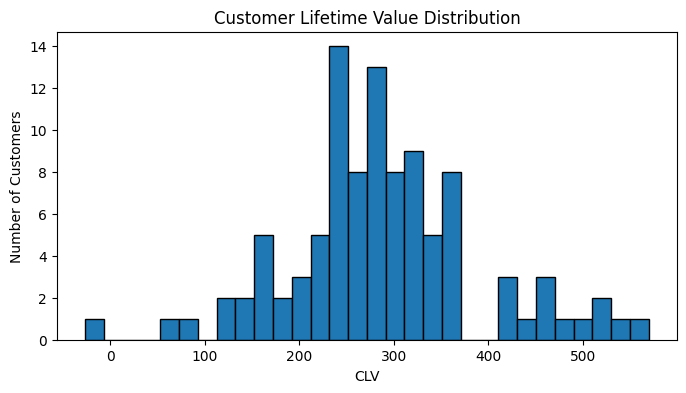

In [10]:
# Data visualization

plt.figure(figsize=(8,4))
plt.hist(summary['predicted_clv'], bins=30, edgecolor='k')
plt.title('Customer Lifetime Value Distribution')
plt.xlabel('CLV')
plt.ylabel('Number of Customers')
plt.show()



In [11]:

# Actionable Insights
summary['CLV_segment'] = pd.qcut(summary['predicted_clv'], 4, labels=['Low', 'Medium', 'High', 'VIP'])

summary.groupby('CLV_segment')['predicted_clv'].mean()

CLV_segment
Low       170.695027
Medium    257.357532
High      304.656915
VIP       417.813079
Name: predicted_clv, dtype: float64

In [ ]:
summary.groupby('CLV_segment')['predicted_clv'].count()
summary.groupby('CLV_segment')['predicted_clv'].std()
summary.groupby('CLV_segment')['predicted_clv'].mean()


CLV_segment
Low       25
Medium    25
High      25
VIP       25
Name: predicted_clv, dtype: int64

In [13]:
summary.groupby('CLV_segment')['predicted_clv'].std()

CLV_segment
Low       62.470786
Medium    13.764227
High      16.527022
VIP       71.227843
Name: predicted_clv, dtype: float64

In [14]:
%pip install nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calcul des métriques par segment
counts = summary.groupby('CLV_segment')['predicted_clv'].count()
stds = summary.groupby('CLV_segment')['predicted_clv'].std()
means = summary.groupby('CLV_segment')['predicted_clv'].mean()

# Couleurs pour chaque segment
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Création de la figure
fig = go.Figure()

# Ajout des graphiques à secteurs pour chaque métrique
fig.add_trace(go.Pie(
    labels=counts.index,
    values=counts.values,
    name="Count",
    visible=True,
    hole=0.6,
    marker_colors=colors,
    textinfo='label+value',
    hoverinfo='label+value+percent'
))

fig.add_trace(go.Pie(
    labels=stds.index,
    values=stds.values,
    name="Standard Deviation",
    visible=False,
    hole=0.6,
    marker_colors=colors,
    textinfo='label+value',
    hoverinfo='label+value+percent'
))

fig.add_trace(go.Pie(
    labels=means.index,
    values=means.values,
    name="Mean",
    visible=False,
    hole=0.6,
    marker_colors=colors,
    textinfo='label+value',
    hoverinfo='label+value+percent'
))

# Mise à jour du layout
fig.update_layout(
    title_text="Analyse des Segments CLV",
    showlegend=True,
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.5,
            y=1.2,
            showactive=True,
            buttons=list([
                dict(
                    label="Count",
                    method="update",
                    args=[{"visible": [True, False, False]}, {"title": "Number of clients per segment"}]),
                dict(
                    label="Standard Deviation",
                    method="update",
                    args=[{"visible": [False, True, False]}, {"title": "Standard Deviation per Segment"}]),
                dict(
                    label="Mean",
                    method="update",
                    args=[{"visible": [False, False, True]}, {"title": "Mean per Segment"}]),
            ]),
        )
    ]
)

fig.show()

- Target High/VIP segments with retention and upsell campaigns.

- Use Low CLV insights to improve onboarding or reduce churn.

### ✅ Proposed Solution

Increase the average CLV per customer by 25% within 6 months through CLV prediction and behavioral segmentation.

✅ Expected Result
- Higher customer retention rate
- Increased average revenue per user (ARPU)
- Lower CAC-to-CLV ratio → stronger long-term profitability

# Solution Steps:

## Data Collection & Preparation

Gather purchase history (date, amount, customer_id).

Clean and transform data to create key metrics: frequency, recency, and monetary value.

## CLV Modeling

Use the BG/NBD + Gamma-Gamma model (via the lifetimes library) to predict:

The expected number of future purchases per customer.

The total expected value (monetary CLV).

## Customer Segmentation

Segment customers based on predicted CLV:

-🔴 Low CLV → reactivation campaigns

-🟡 Medium CLV → loyalty programs

-🟢 High CLV → premium offers, cross-sell, VIP care

## Targeted Marketing Actions

- Personalized emails for each segment

- Smart discounts for at-risk (churn) customers

- Product recommendations based on purchase patterns

## Monitoring & Continuous Optimization

Build a dashboard (Streamlit, Power BI, or Dash) to track:

- Average CLV by segment

- Repeat purchase rate

- ROI of marketing campaigns